In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           46 non-null     int64  
 1   size               46 non-null     int64  
 2   side               46 non-null     object 
 3   order_price        46 non-null     float64
 4   size_multiple      46 non-null     float64
 5   seconds_to_delete  46 non-null     float64
 6   risk_score         46 non-null     int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 2.6+ KB


In [5]:
df.describe()

,order_id,size,order_price,size_multiple,seconds_to_delete,risk_score
count,4.600000e+01,46.000000,46.000000,46.000000,46.000000,46.000000
mean,1.507296e+08,1510.608696,583.332174,27.289783,0.025928,4.021739
std,8.568710e+07,880.122403,2.820386,47.908488,0.021440,1.085032
min,3.493902e+07,1000.000000,578.160000,0.520000,0.000348,3.000000
25%,7.927046e+07,1000.000000,580.997500,8.290000,0.008776,3.000000
50%,1.355772e+08,1200.000000,584.025000,12.000000,0.019439,4.000000
75%,2.458006e+08,2000.000000,586.065000,20.000000,0.036885,5.000000
max,2.668881e+08,6606.000000,586.640000,250.000000,0.075768,7.000000


In [6]:
df.sort_values('risk_score', ascending=False).head(10)

,order_id,size,side,order_price,size_multiple,seconds_to_delete,risk_score
0,266888125,2099,Buy,578.62,20.99,0.000348,7
1,251114227,2000,Sell,579.69,250.00,0.075768,6
2,181083277,2000,Buy,583.02,20.00,0.005518,6
3,181087986,2000,Buy,583.07,20.00,0.008569,6
4,260981833,2000,Buy,578.47,20.00,0.006934,6
5,253792634,1628,Sell,580.15,203.50,0.024979,5
6,180891504,1000,Buy,583.00,27.03,0.005092,5
7,181083701,2000,Buy,583.04,20.00,0.010454,5
8,245797164,2000,Sell,581.02,20.00,0.037180,5
9,245801754,2000,Sell,580.99,20.00,0.070359,5


In [7]:
def risk_level(score):
    if score >= 7:
        return 'High'
    elif score >= 5:
        return 'Medium'
    else:
        return 'Low'

df['risk_level'] = df['risk_score'].apply(risk_level)

df[['order_id', 'size', 'side', 'size_multiple',
    'seconds_to_delete', 'risk_score', 'risk_level']].head(10)

,order_id,size,side,size_multiple,seconds_to_delete,risk_score,risk_level
0,266888125,2099,Buy,20.99,0.000348,7,High
1,251114227,2000,Sell,250.00,0.075768,6,Medium
2,181083277,2000,Buy,20.00,0.005518,6,Medium
3,181087986,2000,Buy,20.00,0.008569,6,Medium
4,260981833,2000,Buy,20.00,0.006934,6,Medium
5,253792634,1628,Sell,203.50,0.024979,5,Medium
6,180891504,1000,Buy,27.03,0.005092,5,Medium
7,181083701,2000,Buy,20.00,0.010454,5,Medium
8,245797164,2000,Sell,20.00,0.037180,5,Medium
9,245801754,2000,Sell,20.00,0.070359,5,Medium


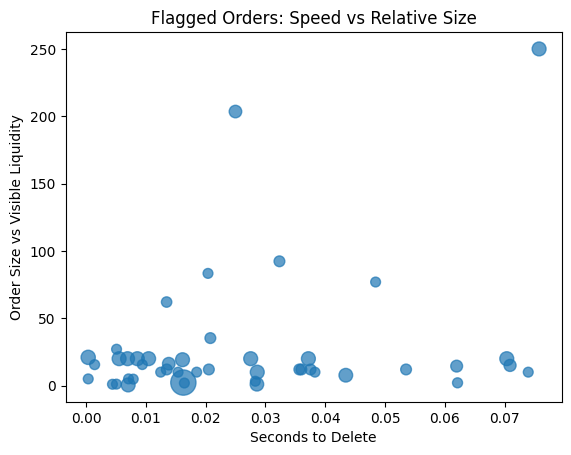

In [8]:
import matplotlib.pyplot as plt

plt.scatter(
    df['seconds_to_delete'],
    df['size_multiple'],
    s=df['size'] / 20,
    alpha=0.7
)

plt.xlabel('Seconds to Delete')
plt.ylabel('Order Size vs Visible Liquidity')
plt.title('Flagged Orders: Speed vs Relative Size')
plt.show()

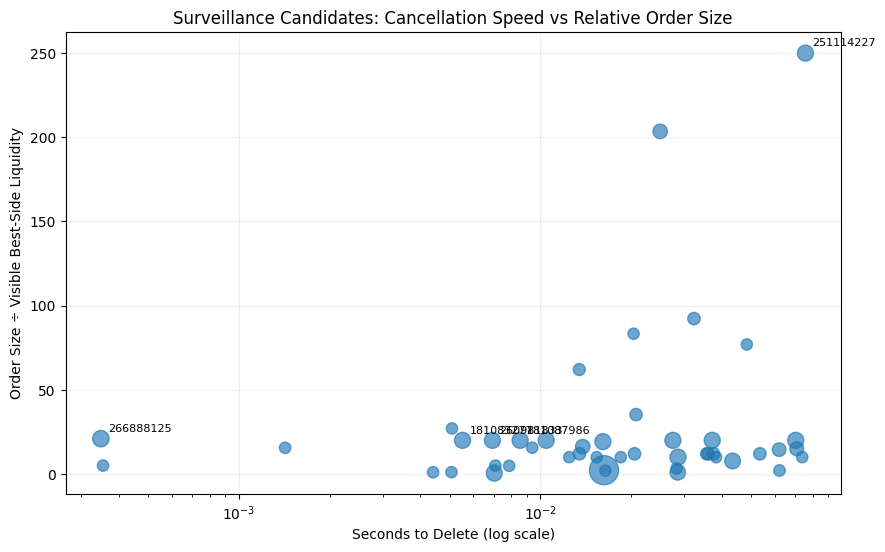

In [9]:
# Rank orders so we can label the strongest surveillance candidates
top_cases = df.sort_values(
    ['risk_score', 'size_multiple'],
    ascending=[False, False]
).head(5)

plt.figure(figsize=(10, 6))

plt.scatter(
    df['seconds_to_delete'],
    df['size_multiple'],
    s=df['size'] / 15,
    alpha=0.65
)

# Log scale makes very tiny cancellation times easier to see
plt.xscale('log')

# Label the five strongest candidates
for _, row in top_cases.iterrows():
    plt.annotate(
        str(row['order_id']),
        (row['seconds_to_delete'], row['size_multiple']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8
    )

plt.xlabel('Seconds to Delete (log scale)')
plt.ylabel('Order Size ÷ Visible Best-Side Liquidity')
plt.title('Surveillance Candidates: Cancellation Speed vs Relative Order Size')

plt.grid(alpha=0.2)
plt.show()

In [10]:
top_cases = (
    df.sort_values(
        ['risk_score', 'size_multiple', 'seconds_to_delete'],
        ascending=[False, False, True]
    )
    .head(10)
    .copy()
)

top_cases['seconds_to_delete'] = top_cases['seconds_to_delete'].round(6)
top_cases['size_multiple'] = top_cases['size_multiple'].round(2)

top_cases[
    [
        'order_id',
        'side',
        'size',
        'order_price',
        'seconds_to_delete',
        'size_multiple',
        'risk_score',
        'risk_level'
    ]
]

,order_id,side,size,order_price,seconds_to_delete,size_multiple,risk_score,risk_level
0,266888125,Buy,2099,578.62,0.000348,20.99,7,High
1,251114227,Sell,2000,579.69,0.075768,250.00,6,Medium
2,181083277,Buy,2000,583.02,0.005518,20.00,6,Medium
4,260981833,Buy,2000,578.47,0.006934,20.00,6,Medium
3,181087986,Buy,2000,583.07,0.008569,20.00,6,Medium
5,253792634,Sell,1628,580.15,0.024979,203.50,5,Medium
6,180891504,Buy,1000,583.00,0.005092,27.03,5,Medium
7,181083701,Buy,2000,583.04,0.010454,20.00,5,Medium
10,260724595,Buy,2000,578.35,0.027527,20.00,5,Medium
8,245797164,Sell,2000,581.02,0.037180,20.00,5,Medium


In [15]:
top_cases = (
    df.sort_values(
        ['risk_score', 'size_multiple', 'seconds_to_delete'],
        ascending=[False, False, True]
    )
    .head(10)
    .reset_index(drop=True)
    .copy()
)

top_cases

,order_id,size,side,order_price,size_multiple,seconds_to_delete,risk_score,risk_level
0,266888125,2099,Buy,578.62,20.99,0.000348,7,High
1,251114227,2000,Sell,579.69,250.00,0.075768,6,Medium
2,181083277,2000,Buy,583.02,20.00,0.005518,6,Medium
3,260981833,2000,Buy,578.47,20.00,0.006934,6,Medium
4,181087986,2000,Buy,583.07,20.00,0.008569,6,Medium
5,253792634,1628,Sell,580.15,203.50,0.024979,5,Medium
6,180891504,1000,Buy,583.00,27.03,0.005092,5,Medium
7,181083701,2000,Buy,583.04,20.00,0.010454,5,Medium
8,260724595,2000,Buy,578.35,20.00,0.027527,5,Medium
9,245797164,2000,Sell,581.02,20.00,0.037180,5,Medium


In [17]:
top_cases.to_csv('top_10_surveillance_candidates.csv', index=False)